In [13]:
# PHASE 4 — CELL 1 — Setup + Monthly revenue trend

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Load cleaned files
clean = '/Users/rahil/Downloads/olist/cleaned/'
delivered     = pd.read_csv(clean + 'olist_delivered_clean.csv',
                            parse_dates=['order_purchase_timestamp',
                                         'order_delivered_customer_date',
                                         'order_estimated_delivery_date'])
rfm           = pd.read_csv(clean + 'olist_rfm_segments.csv')
seller_sc     = pd.read_csv(clean + 'olist_seller_scorecard.csv')
monthly       = pd.read_csv(clean + 'olist_monthly_trend.csv')

# Load originals needed for geographic analysis
path = '/Users/rahil/Downloads/olist/'
customers  = pd.read_csv(path + 'olist_customers_dataset.csv')
items      = pd.read_csv(path + 'olist_order_items_dataset.csv')
products   = pd.read_csv(clean + 'olist_products_clean.csv')

print('Files loaded ✓')
print(f'delivered: {delivered.shape}')
print(f'rfm:       {rfm.shape}')
print(f'monthly:   {monthly.shape}')

# Color palette — consistent across all charts
GREEN  = '#00c48c'
RED    = '#ff5f6d'
AMBER  = '#ffb347'
BLUE   = '#4d8af0'
PURPLE = '#9b79f5'
MUTED  = '#7b82a0'

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor':  '#0f1117',
    'axes.facecolor':    '#1a1d27',
    'axes.edgecolor':    '#2a2d3a',
    'grid.color':        '#2a2d3a',
    'text.color':        '#e8eaf0',
    'xtick.color':       '#7b82a0',
    'ytick.color':       '#7b82a0',
    'axes.labelcolor':   '#e8eaf0',
    'font.size':         10
})

print('Style set ✓')

Files loaded ✓
delivered: (96478, 26)
rfm:       (93358, 9)
monthly:   (20, 6)
Style set ✓


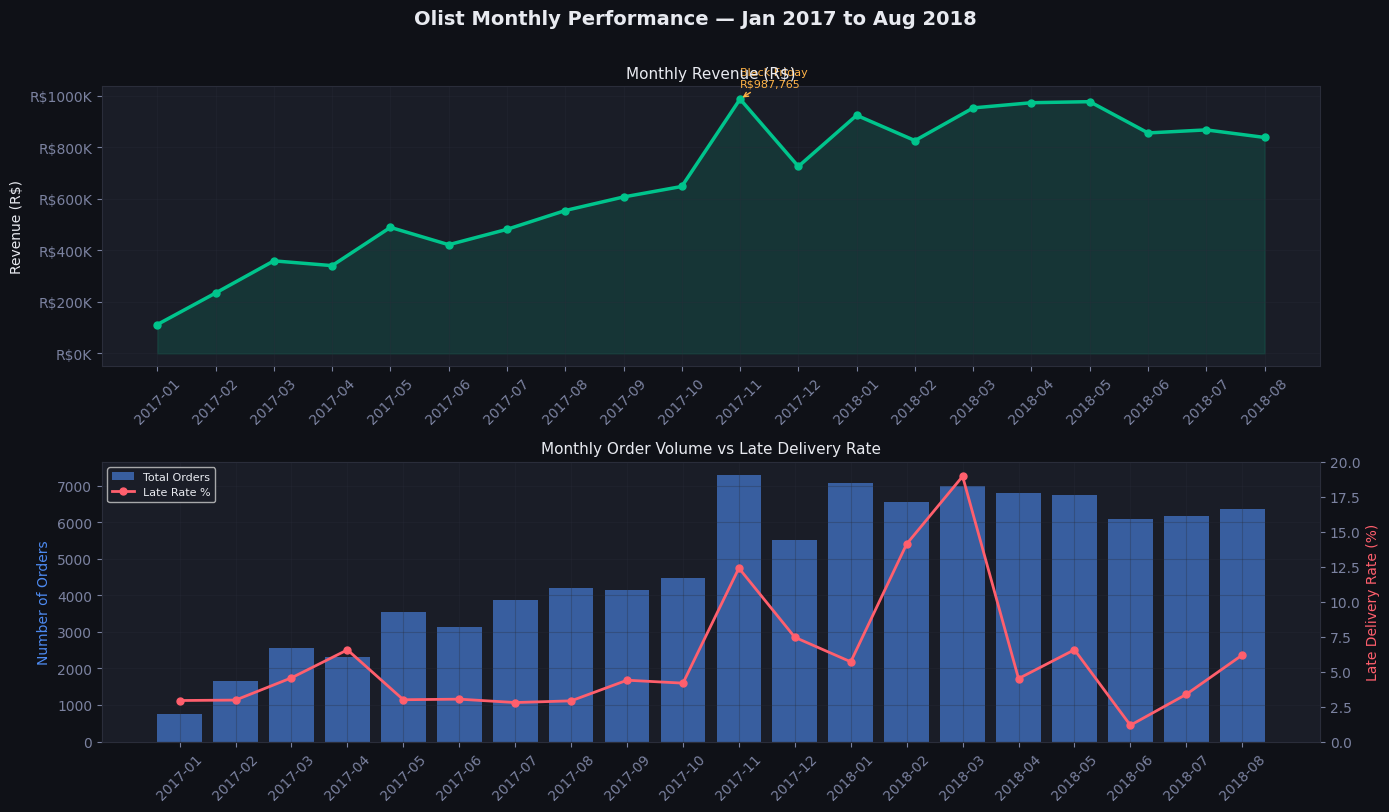

Chart 1 saved ✓


In [14]:
# PHASE 4 — CELL 2 — Monthly revenue + order volume trend

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
fig.suptitle('Olist Monthly Performance — Jan 2017 to Aug 2018',
             fontsize=14, fontweight='bold', y=1.01)

# Filter clean period
monthly_clean = monthly[monthly['month_str'] >= '2017-01'].copy()

# Chart 1 — Revenue trend
ax1 = axes[0]
ax1.plot(monthly_clean['month_str'], monthly_clean['total_revenue'],
         color=GREEN, linewidth=2.5, marker='o', markersize=5)
ax1.fill_between(monthly_clean['month_str'],
                 monthly_clean['total_revenue'],
                 alpha=0.15, color=GREEN)

# Annotate peak
peak_idx = monthly_clean['total_revenue'].idxmax()
peak_month = monthly_clean.loc[peak_idx, 'month_str']
peak_rev   = monthly_clean.loc[peak_idx, 'total_revenue']
ax1.annotate(f'Black Friday\nR${peak_rev:,.0f}',
             xy=(peak_month, peak_rev),
             xytext=(peak_month, peak_rev + 50000),
             fontsize=8, color=AMBER,
             arrowprops=dict(arrowstyle='->', color=AMBER))

ax1.set_title('Monthly Revenue (R$)', fontsize=11)
ax1.set_ylabel('Revenue (R$)')
ax1.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'R${x/1000:.0f}K'))
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Chart 2 — Order volume + late rate
ax2 = axes[1]
ax2_twin = ax2.twinx()

bars = ax2.bar(monthly_clean['month_str'],
               monthly_clean['total_orders'],
               color=BLUE, alpha=0.6, label='Total Orders')
ax2_twin.plot(monthly_clean['month_str'],
              monthly_clean['late_rate'] * 100,
              color=RED, linewidth=2, marker='o',
              markersize=5, label='Late Rate %')

ax2.set_title('Monthly Order Volume vs Late Delivery Rate', fontsize=11)
ax2.set_ylabel('Number of Orders', color=BLUE)
ax2_twin.set_ylabel('Late Delivery Rate (%)', color=RED)
ax2_twin.set_ylim(0, 20)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Combined legend
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('/Users/rahil/Downloads/olist/charts/fig1_monthly_trend.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 1 saved ✓')

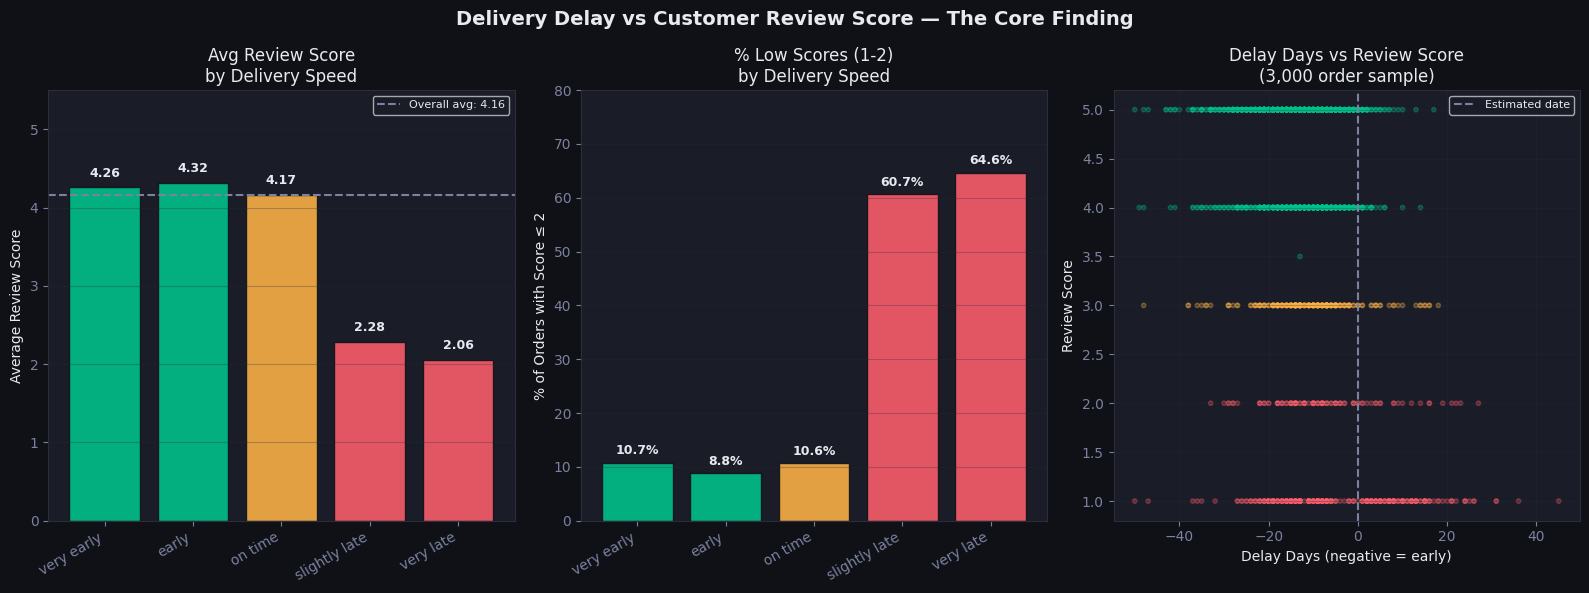

Chart 2 saved ✓


In [15]:
# PHASE 4 — CELL 3 — Delivery delay vs review score (core finding)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Delivery Delay vs Customer Review Score — The Core Finding',
             fontsize=14, fontweight='bold')

speed_order = ['very early', 'early', 'on time', 'slightly late', 'very late']
speed_stats = delivered.groupby('delivery_speed', observed=True).agg(
    total_orders  = ('order_id', 'count'),
    avg_review    = ('review_score', 'mean'),
    pct_low       = ('review_score', lambda x: (x <= 2).mean() * 100),
    pct_high      = ('review_score', lambda x: (x >= 4).mean() * 100)
).reindex(speed_order).reset_index()

colors = [GREEN, GREEN, AMBER, RED, RED]

# Chart 1 — Avg review by delivery speed
ax = axes[0]
bars = ax.bar(range(len(speed_stats)),
              speed_stats['avg_review'],
              color=colors, edgecolor='#0f1117', alpha=0.88)
ax.axhline(delivered['review_score'].mean(),
           color=MUTED, linestyle='--', linewidth=1.5,
           label=f'Overall avg: {delivered["review_score"].mean():.2f}')
ax.set_title('Avg Review Score\nby Delivery Speed')
ax.set_ylabel('Average Review Score')
ax.set_ylim(0, 5.5)
ax.set_xticks(range(len(speed_stats)))
ax.set_xticklabels(speed_stats['delivery_speed'], rotation=30, ha='right')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, speed_stats['avg_review']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=9, color='#e8eaf0', fontweight='bold')

# Chart 2 — % low scores by delivery speed
ax = axes[1]
bars2 = ax.bar(range(len(speed_stats)),
               speed_stats['pct_low'],
               color=colors, edgecolor='#0f1117', alpha=0.88)
ax.set_title('% Low Scores (1-2)\nby Delivery Speed')
ax.set_ylabel('% of Orders with Score ≤ 2')
ax.set_ylim(0, 80)
ax.set_xticks(range(len(speed_stats)))
ax.set_xticklabels(speed_stats['delivery_speed'], rotation=30, ha='right')
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, speed_stats['pct_low']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=9, color='#e8eaf0', fontweight='bold')

# Chart 3 — Scatter
ax = axes[2]
sample = delivered[
    delivered['delivery_delay_days'].between(-50, 50) &
    delivered['review_score'].notna()
].sample(3000, random_state=42).copy()

sample['review_score_rounded'] = sample['review_score'].round()
sample['review_score_rounded'] = sample['review_score_rounded'].fillna(3)
sample['review_score_rounded'] = sample['review_score_rounded'].astype(int)

scatter_colors = sample['review_score_rounded'].map({
    1: RED, 2: RED, 3: AMBER, 4: GREEN, 5: GREEN
}).fillna(MUTED)

ax.scatter(sample['delivery_delay_days'],
           sample['review_score'],
           c=scatter_colors.tolist(),
           alpha=0.3, s=10)
ax.axvline(0, color=MUTED, linestyle='--',
           linewidth=1.5, label='Estimated date')
ax.set_title('Delay Days vs Review Score\n(3,000 order sample)')
ax.set_xlabel('Delay Days (negative = early)')
ax.set_ylabel('Review Score')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rahil/Downloads/olist/charts/fig2_delay_vs_review.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 2 saved ✓')

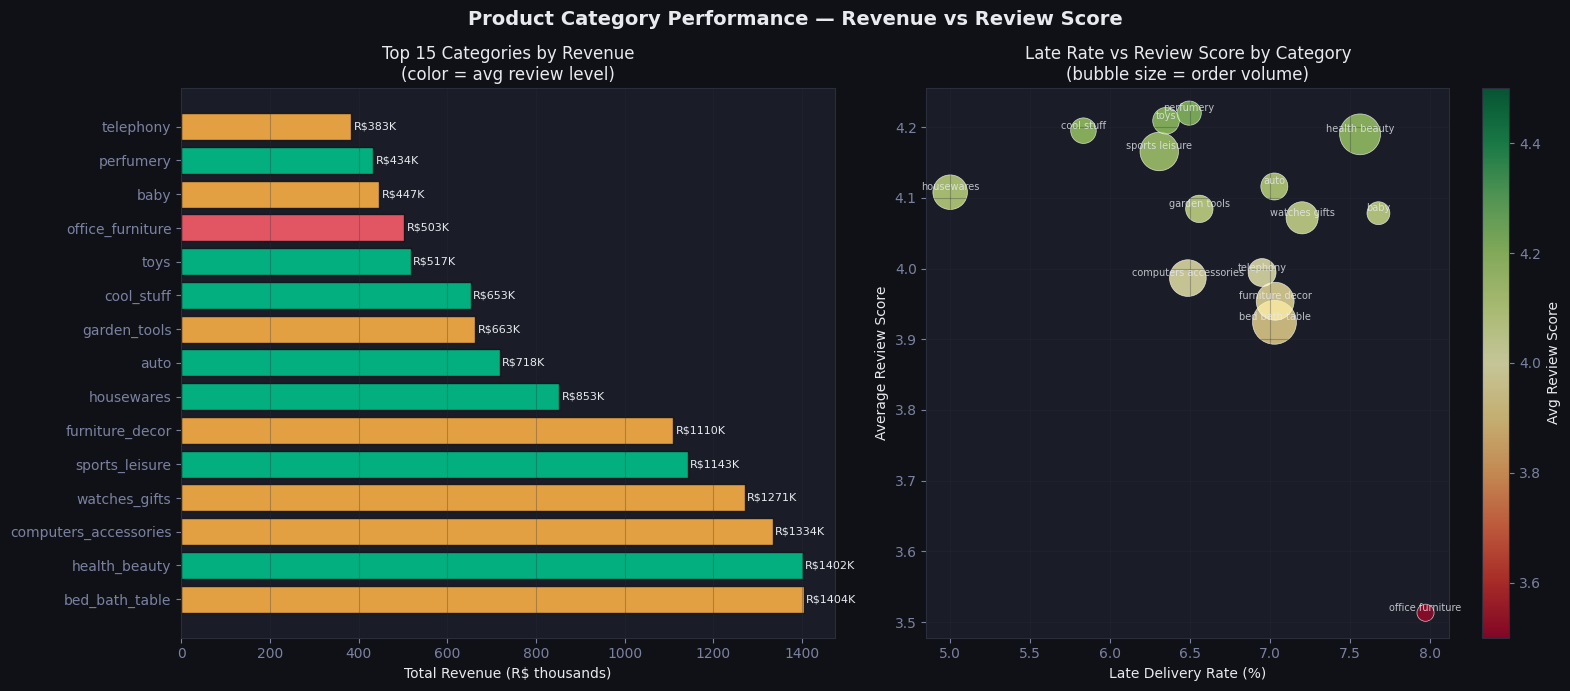

Chart 3 saved ✓


In [16]:
# PHASE 4 — CELL 4 — Product category analysis

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Product Category Performance — Revenue vs Review Score',
             fontsize=14, fontweight='bold')

# Build category stats
cat_stats = delivered.merge(
    items[['order_id', 'product_id']],
    on='order_id', how='left'
).merge(
    products[['product_id', 'product_category_name_english']],
    on='product_id', how='left'
)

cat_summary = cat_stats.groupby('product_category_name_english').agg(
    total_orders  = ('order_id', 'count'),
    total_revenue = ('total_revenue', 'sum'),
    avg_review    = ('review_score', 'mean'),
    late_pct      = ('is_late', 'mean')
).reset_index()

# Filter top 15 by revenue, exclude unknown
cat_top = cat_summary[
    cat_summary['product_category_name_english'] != 'unknown'
].nlargest(15, 'total_revenue')

# Chart 1 — Revenue by category (horizontal bar)
ax = axes[0]
rev_colors = [GREEN if r >= 4.1 else AMBER if r >= 3.9 else RED
              for r in cat_top['avg_review']]
bars = ax.barh(cat_top['product_category_name_english'],
               cat_top['total_revenue'] / 1000,
               color=rev_colors, edgecolor='#0f1117', alpha=0.88)
ax.set_title('Top 15 Categories by Revenue\n(color = avg review level)')
ax.set_xlabel('Total Revenue (R$ thousands)')
ax.grid(True, axis='x', alpha=0.3)

for bar, val in zip(bars, cat_top['total_revenue']):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'R${val/1000:.0f}K', va='center', fontsize=8,
            color='#e8eaf0')

# Chart 2 — Review score vs late rate bubble chart
ax = axes[1]
bubble_size = cat_top['total_orders'] / cat_top['total_orders'].max() * 1000

scatter = ax.scatter(
    cat_top['late_pct'] * 100,
    cat_top['avg_review'],
    s=bubble_size,
    c=cat_top['avg_review'],
    cmap='RdYlGn',
    alpha=0.75,
    edgecolors='white',
    linewidth=0.5,
    vmin=3.5, vmax=4.5
)

# Label each bubble
for _, row in cat_top.iterrows():
    ax.annotate(
        row['product_category_name_english'].replace('_', ' '),
        (row['late_pct'] * 100, row['avg_review']),
        fontsize=7, ha='center', va='bottom',
        color='#e8eaf0', alpha=0.8
    )

ax.set_title('Late Rate vs Review Score by Category\n(bubble size = order volume)')
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Average Review Score')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Avg Review Score')

plt.tight_layout()
plt.savefig('/Users/rahil/Downloads/olist/charts/fig3_category_analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 3 saved ✓')

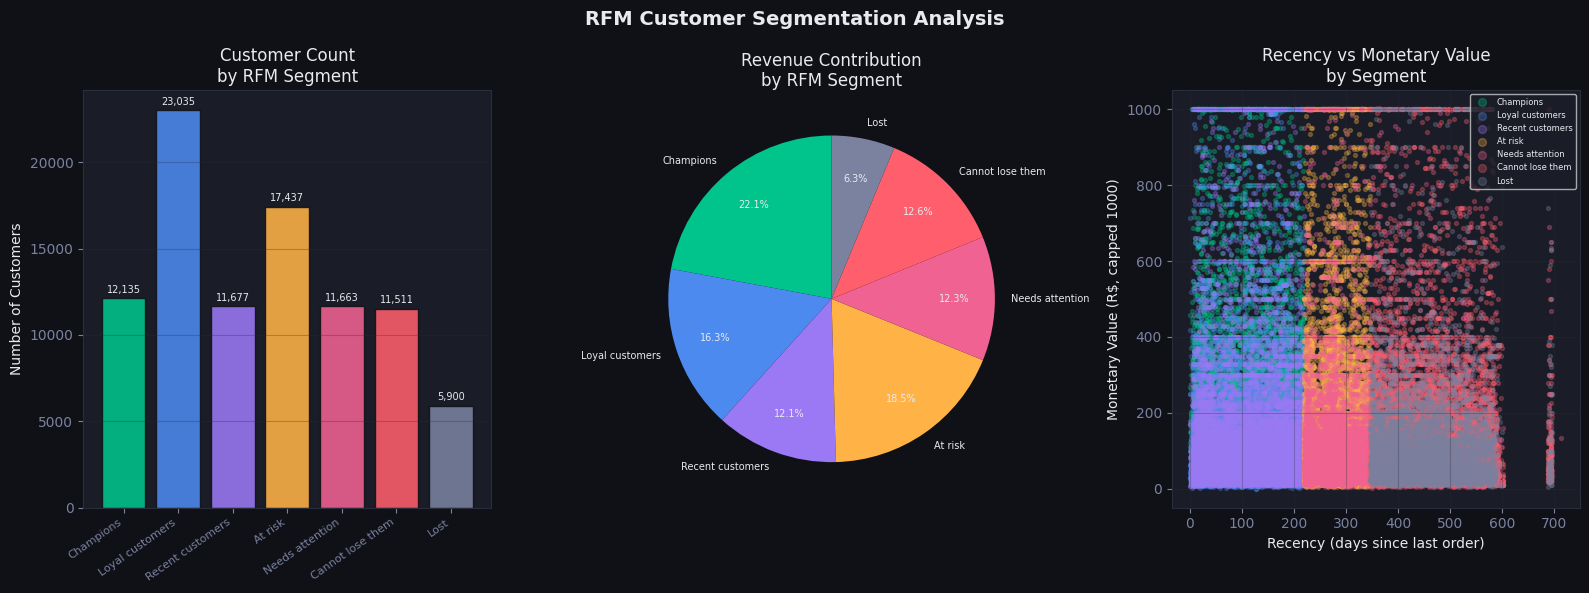

Chart 4 saved ✓


In [17]:
# PHASE 4 — CELL 5 — RFM segment visualisation

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('RFM Customer Segmentation Analysis',
             fontsize=14, fontweight='bold')

# Segment order and colors
seg_colors = {
    'Champions':        GREEN,
    'Loyal customers':  BLUE,
    'Recent customers': PURPLE,
    'At risk':          AMBER,
    'Needs attention':  '#f06292',
    'Cannot lose them': RED,
    'Lost':             MUTED
}

seg_order = list(seg_colors.keys())
seg_summary = rfm.groupby('segment').agg(
    customers     = ('customer_unique_id', 'count'),
    avg_recency   = ('recency', 'mean'),
    avg_monetary  = ('monetary', 'mean'),
    total_revenue = ('monetary', 'sum')
).reindex(seg_order).reset_index()

seg_summary['revenue_pct'] = (
    seg_summary['total_revenue'] /
    seg_summary['total_revenue'].sum() * 100
)

colors_list = [seg_colors[s] for s in seg_summary['segment']]

# Chart 1 — Customer count by segment
ax = axes[0]
bars = ax.bar(range(len(seg_summary)),
              seg_summary['customers'],
              color=colors_list, edgecolor='#0f1117', alpha=0.88)
ax.set_title('Customer Count\nby RFM Segment')
ax.set_ylabel('Number of Customers')
ax.set_xticks(range(len(seg_summary)))
ax.set_xticklabels(seg_summary['segment'], rotation=35, ha='right', fontsize=8)
ax.grid(True, axis='y', alpha=0.3)

for bar, val in zip(bars, seg_summary['customers']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f'{val:,}', ha='center', va='bottom',
            fontsize=7, color='#e8eaf0')

# Chart 2 — Revenue contribution (pie chart)
ax = axes[1]
wedges, texts, autotexts = ax.pie(
    seg_summary['revenue_pct'],
    labels=seg_summary['segment'],
    colors=colors_list,
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.75,
    textprops={'fontsize': 7, 'color': '#e8eaf0'}
)
for autotext in autotexts:
    autotext.set_fontsize(7)
ax.set_title('Revenue Contribution\nby RFM Segment')

# Chart 3 — Recency vs Monetary scatter
ax = axes[2]
for seg, color in seg_colors.items():
    subset = rfm[rfm['segment'] == seg]
    ax.scatter(subset['recency'],
               subset['monetary'].clip(0, 1000),
               c=color, alpha=0.3, s=8,
               label=seg)

ax.set_title('Recency vs Monetary Value\nby Segment')
ax.set_xlabel('Recency (days since last order)')
ax.set_ylabel('Monetary Value (R$, capped 1000)')
ax.legend(fontsize=6, loc='upper right',
          markerscale=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/rahil/Downloads/olist/charts/fig4_rfm_segments.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 4 saved ✓')

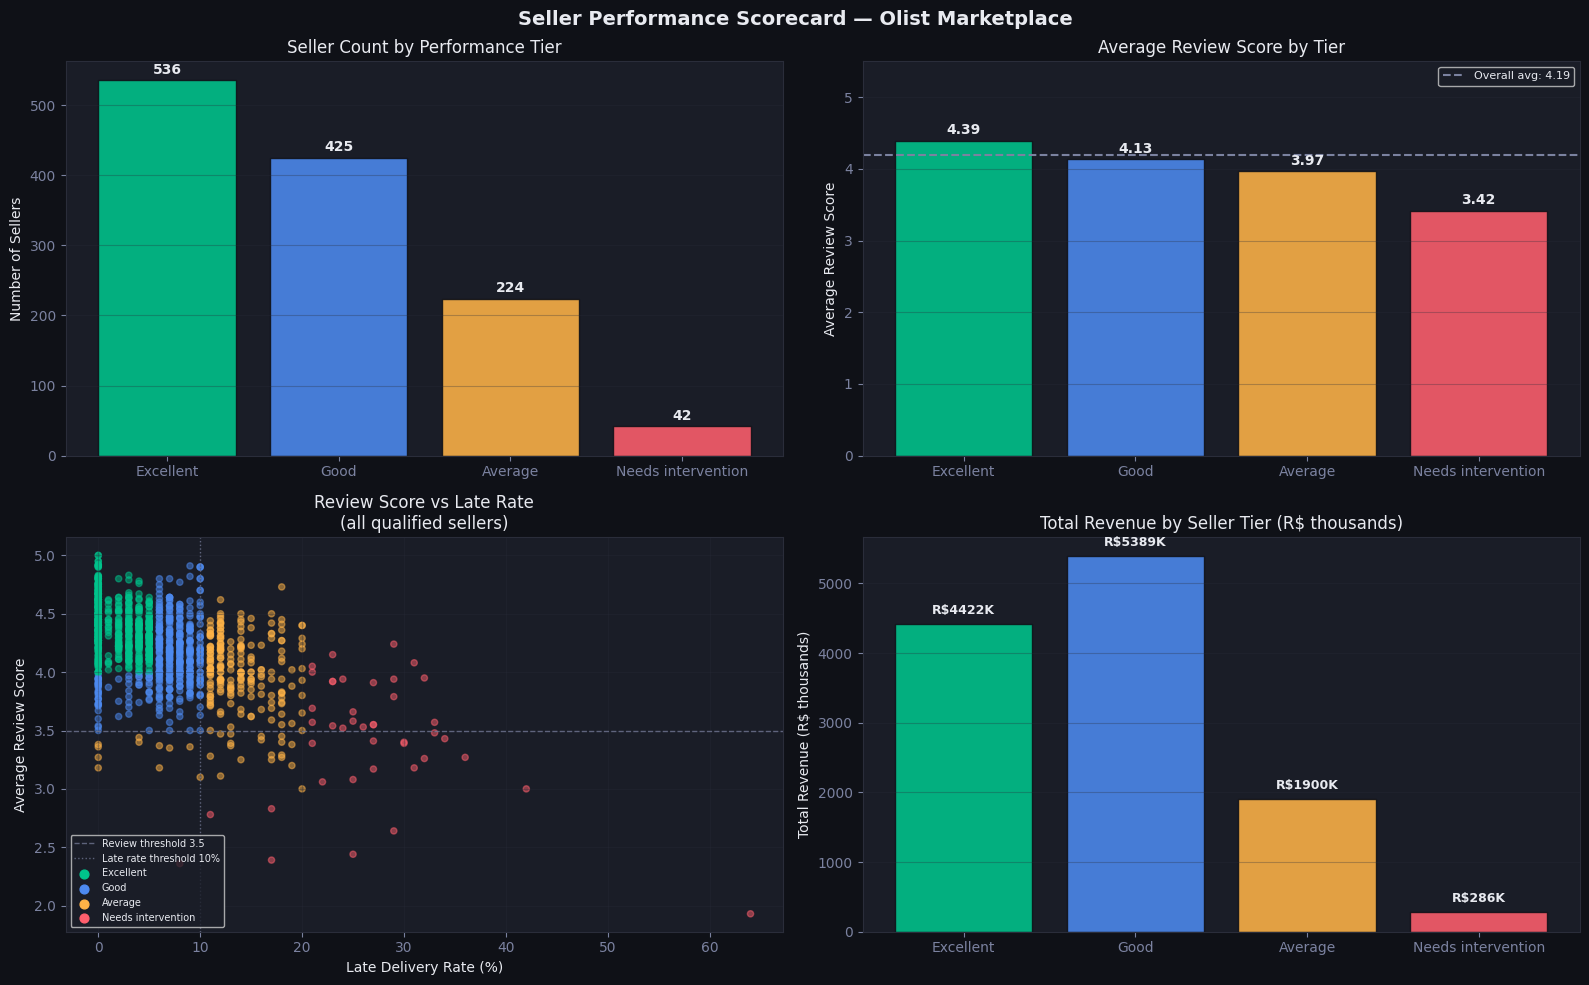

Chart 5 saved ✓


In [18]:
# PHASE 4 — CELL 6 — Seller scorecard visualisation

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Seller Performance Scorecard — Olist Marketplace',
             fontsize=14, fontweight='bold')

# Tier colors
tier_colors = {
    'A — Excellent':          GREEN,
    'B — Good':               BLUE,
    'C — Average':            AMBER,
    'D — Needs intervention': RED
}

tier_order = list(tier_colors.keys())
tier_summary = seller_sc.groupby('seller_tier').agg(
    sellers       = ('seller_id', 'count'),
    avg_review    = ('avg_review', 'mean'),
    avg_late_rate = ('late_rate', 'mean'),
    total_revenue = ('total_revenue', 'sum')
).reindex(tier_order).reset_index()

colors_list = [tier_colors[t] for t in tier_summary['seller_tier']]

# Chart 1 — Seller count by tier
ax = axes[0, 0]
bars = ax.bar(range(len(tier_summary)),
              tier_summary['sellers'],
              color=colors_list, edgecolor='#0f1117', alpha=0.88)
ax.set_title('Seller Count by Performance Tier')
ax.set_ylabel('Number of Sellers')
ax.set_xticks(range(len(tier_summary)))
ax.set_xticklabels([t.split(' — ')[1] for t in tier_summary['seller_tier']],
                   rotation=0)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars, tier_summary['sellers']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 5,
            str(val), ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#e8eaf0')

# Chart 2 — Avg review by tier
ax = axes[0, 1]
bars2 = ax.bar(range(len(tier_summary)),
               tier_summary['avg_review'],
               color=colors_list, edgecolor='#0f1117', alpha=0.88)
ax.set_title('Average Review Score by Tier')
ax.set_ylabel('Average Review Score')
ax.set_ylim(0, 5.5)
ax.set_xticks(range(len(tier_summary)))
ax.set_xticklabels([t.split(' — ')[1] for t in tier_summary['seller_tier']],
                   rotation=0)
ax.axhline(seller_sc['avg_review'].mean(), color=MUTED,
           linestyle='--', linewidth=1.5,
           label=f'Overall avg: {seller_sc["avg_review"].mean():.2f}')
ax.legend(fontsize=8)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars2, tier_summary['avg_review']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05,
            f'{val:.2f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color='#e8eaf0')

# Chart 3 — Review score vs late rate scatter (all sellers)
ax = axes[1, 0]
tier_color_map = seller_sc['seller_tier'].map(tier_colors)
ax.scatter(seller_sc['late_rate'] * 100,
           seller_sc['avg_review'],
           c=tier_color_map.tolist(),
           alpha=0.5, s=20)
ax.axhline(3.5, color=MUTED, linestyle='--',
           linewidth=1, alpha=0.7, label='Review threshold 3.5')
ax.axvline(10, color=MUTED, linestyle=':',
           linewidth=1, alpha=0.7, label='Late rate threshold 10%')
ax.set_title('Review Score vs Late Rate\n(all qualified sellers)')
ax.set_xlabel('Late Delivery Rate (%)')
ax.set_ylabel('Average Review Score')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# Add tier legend
for tier, color in tier_colors.items():
    ax.scatter([], [], c=color, label=tier.split(' — ')[1], s=40)
ax.legend(fontsize=7, loc='lower left')

# Chart 4 — Revenue by tier
ax = axes[1, 1]
bars4 = ax.bar(range(len(tier_summary)),
               tier_summary['total_revenue'] / 1000,
               color=colors_list, edgecolor='#0f1117', alpha=0.88)
ax.set_title('Total Revenue by Seller Tier (R$ thousands)')
ax.set_ylabel('Total Revenue (R$ thousands)')
ax.set_xticks(range(len(tier_summary)))
ax.set_xticklabels([t.split(' — ')[1] for t in tier_summary['seller_tier']],
                   rotation=0)
ax.grid(True, axis='y', alpha=0.3)
for bar, val in zip(bars4, tier_summary['total_revenue']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'R${val/1000:.0f}K', ha='center', va='bottom',
            fontsize=9, fontweight='bold', color='#e8eaf0')

plt.tight_layout()
plt.savefig('/Users/rahil/Downloads/olist/charts/fig5_seller_scorecard.png',
            dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()
print('Chart 5 saved ✓')

In [20]:
import os
charts_path = '/Users/rahil/Downloads/olist/charts/'
files = sorted(os.listdir(charts_path))
print(f'Total charts: {len(files)}')
for f in files:
    size = os.path.getsize(charts_path + f) / 1024
    print(f'  {f}  —  {size:.0f} KB')

Total charts: 5
  fig1_monthly_trend.png  —  179 KB
  fig2_delay_vs_review.png  —  161 KB
  fig3_category_analysis.png  —  195 KB
  fig4_rfm_segments.png  —  594 KB
  fig5_seller_scorecard.png  —  280 KB
